# Lab 3: Actor-Critic Methods

## TDDE78 — Deep Reinforcement Learning
### Linköping University, Spring 2026

---

In this lab you will implement two fundamental **actor-critic** algorithms:
- **A2C (Advantage Actor-Critic with GAE)** — an on-policy method combining rollout-based data collection with Generalized Advantage Estimation
- **SAC (Soft Actor-Critic)** — a state-of-the-art off-policy algorithm for continuous control with entropy regularization and twin Q-networks

The lab is divided into:
- **Part A** — Implementation (fill in the TODO sections)
- **Part B** — Experiments (run systematic evaluations and analyze results)

**Instructions:** Complete all cells marked with `# TODO`. Do not modify the provided helper code unless explicitly asked.

## Setup

Run the cell below to import all necessary libraries and verify your environment.

In [6]:
import os
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import Video, display
import warnings
warnings.filterwarnings('ignore')

# Import lab utilities
from networks import ContinuousActorCritic, SACActor, SACCritic
from utils import compute_gae, RolloutBuffer, ReplayBuffer, plot_a2c_results, plot_sac_results, plot_comparison, record_agent_video, smooth

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Resolve experiments directory relative to this notebook's location
_here = globals().get('__vsc_ipynb_file__', os.path.abspath(''))
_nb_dir = os.path.dirname(_here) if os.path.isfile(_here) else _here
EXPERIMENTS_DIR = os.path.normpath(os.path.join(_nb_dir, '..', 'experiments'))
print(f"Experiments directory: {EXPERIMENTS_DIR}")

# For reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed(42)
print("Setup complete!")

Using device: cpu
Experiments directory: c:\Users\SEJEVIB1\Desktop\tdde78lab\labs\lab3_actor_critic\experiments
Setup complete!


---

# Part A — Implementation

---

## A.1 — Explore the Environment

We'll work with **LunarLanderContinuous-v3** — a continuous control task where the agent must land a spacecraft between two flags.

- **State:** 8-dimensional vector (position x/y, velocity x/y, angle, angular velocity, leg contacts)
- **Actions:** 2 continuous values — main engine thrust and side engine thrust, both in \([-1, 1]\)
- **Reward:** +100 for landing, -100 for crash, small rewards for each leg contact, penalty for using fuel
- **Solved:** Average reward ≥ 200 over 100 consecutive episodes

In [2]:
# Explore the LunarLanderContinuous environment
env = gym.make('LunarLanderContinuous-v3')

print(f"Observation space: {env.observation_space}")
print(f"  Shape: {env.observation_space.shape}")
print(f"  Low:   {env.observation_space.low}")
print(f"  High:  {env.observation_space.high}")
print()
print(f"Action space: {env.action_space}")
print(f"  Shape: {env.action_space.shape}")
print(f"  Low:   {env.action_space.low}")
print(f"  High:  {env.action_space.high}")

# Run a random episode
obs, info = env.reset(seed=42)
total_reward = 0
for step in range(1000):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    if terminated or truncated:
        break

print(f"\nRandom agent — Episode length: {step+1}, Total reward: {total_reward:.1f}")
env.close()

Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
  Shape: (8,)
  Low:   [ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ]
  High:  [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ]

Action space: Box(-1.0, 1.0, (2,), float32)
  Shape: (2,)
  Low:   [-1. -1.]
  High:  [1. 1.]

Random agent — Episode length: 231, Total reward: -97.3


## A.2 — Utility Functions (provided)

`utils.py` is **fully implemented** — you do **not** need to modify it.

It provides:
- **`compute_gae()`** — Generalized Advantage Estimation (backwards pass over the rollout)
- **`RolloutBuffer`** — on-policy buffer for A2C (stores states, actions, rewards, GAE advantages)
- **`ReplayBuffer`** — off-policy buffer for SAC (random-access replay with fixed capacity)
- **Plotting helpers** — `plot_a2c_results`, `plot_sac_results`, `plot_comparison`
- **`record_agent_video`** — records MP4 of a trained agent

Run the cells below to verify that everything works before moving on.

In [3]:
# Test compute_gae
from utils import compute_gae

# Simple 3-step example: rewards=[1,1,1], values=[0,0,0], done=[F,F,T], last_value=0
rewards    = [1.0, 1.0, 1.0]
values     = [0.0, 0.0, 0.0]
dones      = [False, False, True]
last_value = 0.0
gamma, lam = 0.99, 0.95

advs, rets = compute_gae(rewards, values, dones, last_value, gamma, lam)

assert advs.shape == (3,), f"Expected shape (3,), got {advs.shape}"
assert rets.shape  == (3,), f"Expected shape (3,), got {rets.shape}"
assert advs.dtype  == np.float32

# With lambda=1 and zero values, advantages equal MC returns
advs_mc, _ = compute_gae(rewards, values, dones, last_value, gamma, gae_lambda=1.0)
expected_G  = np.array([1 + 0.99 + 0.99**2, 1 + 0.99, 1.0], dtype=np.float32)
np.testing.assert_allclose(advs_mc, expected_G, rtol=1e-5,
                            err_msg="Lambda=1 should give MC returns")

print("compute_gae tests passed!")
print(f"  advantages (λ=0.95): {advs}")
print(f"  returns    (λ=0.95): {rets}")
print(f"  advantages (λ=1.0 ): {advs_mc}  ← should equal MC returns {expected_G}")

compute_gae tests passed!
  advantages (λ=0.95): [2.8250403 1.9405    1.       ]
  returns    (λ=0.95): [2.8250403 1.9405    1.       ]
  advantages (λ=1.0 ): [2.9701 1.99   1.    ]  ← should equal MC returns [2.9701 1.99   1.    ]


In [4]:
# Sanity-check RolloutBuffer (A2C)
from utils import RolloutBuffer

buf = RolloutBuffer(n_steps=10, state_dim=8, action_dim=2)
for i in range(10):
    buf.store(
        state    = np.zeros(8, dtype=np.float32),
        action   = np.array([0.1, -0.1], dtype=np.float32),
        reward   = 1.0,
        done     = (i == 9),
        log_prob = -1.0,
        value    = 0.5,
    )

assert len(buf) == 10, f"Expected 10, got {len(buf)}"

buf.compute_returns_and_advantages(last_value=0.0, gamma=0.99, gae_lambda=0.95)
assert buf.advantages is not None and buf.returns is not None, "advantages/returns not set"

batches = list(buf.get_batches(batch_size=5))
assert len(batches) == 2, f"Expected 2 batches, got {len(batches)}"
states, actions, old_log_probs, advantages, returns = batches[0]
assert states.shape    == (5, 8), f"states: {states.shape}"
assert actions.shape   == (5, 2), f"actions: {actions.shape}"
assert advantages.shape == (5,),  f"advantages: {advantages.shape}"

print("RolloutBuffer tests passed!")

# Sanity-check ReplayBuffer (SAC)
from utils import ReplayBuffer

rb = ReplayBuffer(capacity=1000, state_dim=8, action_dim=2, seed=42)
for i in range(100):
    rb.push(
        state      = np.zeros(8, dtype=np.float32),
        action     = np.array([0.1, -0.1], dtype=np.float32),
        reward     = 1.0,
        next_state = np.ones(8, dtype=np.float32),
        done       = False,
    )
assert len(rb) == 100

states, actions, rewards, next_states, dones = rb.sample(batch_size=32)
assert states.shape      == (32, 8), f"states: {states.shape}"
assert actions.shape     == (32, 2), f"actions: {actions.shape}"
assert rewards.shape     == (32, 1), f"rewards should be (32,1), got {rewards.shape}"
assert next_states.shape == (32, 8), f"next_states: {next_states.shape}"
assert dones.shape       == (32, 1), f"dones should be (32,1), got {dones.shape}"

print("ReplayBuffer tests passed!")

RolloutBuffer tests passed!
ReplayBuffer tests passed!


## A.3 — Network Architectures

Open `networks.py` and implement the three network classes:

**`ContinuousActorCritic`** (for A2C):
```
state_dim → 256 → Tanh → 256 → Tanh
                                    ├── → action_dim   [actor: mean μ(s)]
                                    └── → 1            [critic: V(s)]
log_std: nn.Parameter(zeros)  [learnable, shared across states]
```

**`SACActor`** (for SAC — reparameterized Gaussian with tanh squashing):
```
state_dim → 256 → ReLU → 256 → ReLU
                                     ├── → action_dim  [mean μ(s)]
                                     └── → action_dim  [log std log σ(s), clamped]
```

**`SACCritic`** (for SAC — twin Q-networks):
```
[state | action] → 256 → ReLU → 256 → ReLU → 1   (×2 independent networks)
```

In [5]:
# Test ContinuousActorCritic
from networks import ContinuousActorCritic

net = ContinuousActorCritic(state_dim=8, action_dim=2).to(device)
test_states = torch.randn(4, 8).to(device)

mean, value = net(test_states)
assert mean.shape  == (4, 2), f"mean shape: {mean.shape}"
assert value.shape == (4, 1), f"value shape: {value.shape}"

action, log_prob, entropy, value2 = net.get_action(test_states)
assert action.shape   == (4, 2), f"action shape: {action.shape}"
assert log_prob.shape == (4,),   f"log_prob shape: {log_prob.shape}"
assert entropy.shape  == (4,),   f"entropy shape: {entropy.shape}"

n_params = sum(p.numel() for p in net.parameters())
print(f"ContinuousActorCritic — parameters: {n_params:,}")
print(f"  mean: {mean.shape}, value: {value.shape}")
print("ContinuousActorCritic tests passed!")

# Test SACActor
from networks import SACActor

actor = SACActor(state_dim=8, action_dim=2).to(device)
action, log_prob = actor.get_action(test_states)
assert action.shape   == (4, 2), f"action shape: {action.shape}"
assert log_prob.shape == (4,),   f"log_prob shape: {log_prob.shape}"
assert action.abs().max().item() < 1.0, "SAC actions must be in (-1,1) after tanh"

n_params = sum(p.numel() for p in actor.parameters())
print(f"\nSACActor — parameters: {n_params:,}")
print(f"  action range: [{action.min().item():.3f}, {action.max().item():.3f}]  ← must be in (-1,1)")
print("SACActor tests passed!")

# Test SACCritic
from networks import SACCritic

critic = SACCritic(state_dim=8, action_dim=2).to(device)
test_actions = torch.randn(4, 2).to(device)
q1, q2 = critic(test_states, test_actions)
assert q1.shape == (4, 1), f"q1 shape: {q1.shape}"
assert q2.shape == (4, 1), f"q2 shape: {q2.shape}"

n_params = sum(p.numel() for p in critic.parameters())
print(f"\nSACCritic (twin) — parameters: {n_params:,}")
print(f"  q1: {q1.shape}, q2: {q2.shape}")
print("SACCritic tests passed!")

ContinuousActorCritic — parameters: 68,869
  mean: torch.Size([4, 2]), value: torch.Size([4, 1])
ContinuousActorCritic tests passed!

SACActor — parameters: 69,124
  action range: [-0.996, 0.690]  ← must be in (-1,1)
SACActor tests passed!

SACCritic (twin) — parameters: 137,730
  q1: torch.Size([4, 1]), q2: torch.Size([4, 1])
SACCritic tests passed!


## A.4 — A2C Agent

Implement the complete A2C agent. Key steps:
1. **`collect_rollout()`** — run the policy for `n_steps` steps and store transitions in `self.buffer`
2. **`update()`** — compute the A2C loss and perform one gradient update

**A2C Loss:**
$$\mathcal{L} = \underbrace{-\mathbb{E}[\log\pi_\theta(a|s) \cdot \hat{A}]}_{\text{policy loss}} + \underbrace{c_V \cdot \mathbb{E}[(V(s) - R)^2]}_{\text{value loss}} - \underbrace{c_H \cdot \mathcal{H}[\pi]}_{\text{entropy bonus}}$$

In [ ]:
class A2CAgent:
    """
    Advantage Actor-Critic (A2C) agent for continuous control.

    Collects n_steps transitions, computes GAE advantages, then performs
    one gradient update on the actor and critic simultaneously.

    Args:
        state_dim     (int):   Dimension of state space.
        action_dim    (int):   Dimension of continuous action space.
        lr            (float): Learning rate.
        gamma         (float): Discount factor.
        gae_lambda    (float): GAE lambda parameter.
        n_steps       (int):   Steps per rollout (one update per rollout).
        batch_size    (int):   Mini-batch size (unused — A2C does one full-rollout update).
        vf_coef       (float): Coefficient for value loss.
        ent_coef      (float): Coefficient for entropy bonus.
        max_grad_norm (float): Gradient clipping norm.
        seed          (int):   Random seed.
    """

    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        lr: float = 3e-4,
        gamma: float = 0.99,
        gae_lambda: float = 0.95,
        n_steps: int = 2048,
        batch_size: int = 64,
        vf_coef: float = 0.5,
        ent_coef: float = 0.0,
        max_grad_norm: float = 0.5,
        seed: int = 42,
    ):
        self.gamma         = gamma
        self.gae_lambda    = gae_lambda
        self.n_steps       = n_steps
        self.batch_size    = batch_size
        self.vf_coef       = vf_coef
        self.ent_coef      = ent_coef
        self.max_grad_norm = max_grad_norm

        # =====================================================================
        # TODO: Initialize the following:
        #
        # 1. self.network   — ContinuousActorCritic(state_dim, action_dim) moved to device
        # 2. self.optimizer — Adam optimizer for self.network.parameters() with lr
        # 3. self.buffer    — RolloutBuffer(n_steps, state_dim, action_dim)
        # =====================================================================
        
        self.network = ContinuousActorCritic(state_dim, action_dim).to(device)
        self.optimizer = optim.Adam(self.network.parameters(), lr=lr)
        self.buffer = RolloutBuffer(n_steps, state_dim, action_dim)

    @torch.no_grad()
    def collect_rollout(self, env, obs):
        """
        Collect n_steps transitions from the environment using the current policy.

        Args:
            env: Gymnasium environment (already reset; obs is the current state).
            obs: Current observation as numpy array of shape (state_dim,).

        Returns:
            obs:             Next observation after the rollout ends.
            last_value:      V(s_T) — bootstrapped value for the final state.
            episode_rewards: List of total rewards for any episodes completed.
        """
        
        self.buffer.clear()
        episode_rewards   = []
        current_ep_reward = 0.0
        last_done         = False

        # =====================================================================
        # TODO: Implement the rollout collection loop.
        #
        # For each step in range(self.n_steps):
        #   1. Convert obs to a (1, state_dim) FloatTensor on device
        #   2. Call self.network.get_action(state_t) to get action, log_prob, entropy, value
        #      - Convert action to numpy, extract scalar log_prob and value
        #   3. Step the environment: next_obs, reward, terminated, truncated, _
        #      - done = terminated or truncated
        #   4. Store the transition in self.buffer
        #   5. Track episode reward; on done append to episode_rewards and reset env
        #   6. Update obs and last_done
        #
        # After the loop, bootstrap last_value from the current policy:
        #   - If last_done is True, last_value = 0.0
        #   - Otherwise, call self.network forward to get V(obs)
        #
        # Return obs, last_value, episode_rewards
        # =====================================================================
        for step in range(self.n_steps):
            state_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            action, log_prob, entropy, value = self.network.get_action(state_t)
            
            action_np = action.squeeze(0).cpu().numpy()
            log_prob_scalar = log_prob.item()
            value_scalar = value.squeeze(-1).item()
            
            next_obs, reward, terminated, truncated, _ = env.step(action_np)
            done = terminated or truncated
            
            self.buffer.store(
                state=obs,
                action=action_np,
                reward=reward,
                done=done,
                log_prob=log_prob_scalar,
                value=value_scalar,
            )
            
            current_ep_reward += reward
            if done:
                episode_rewards.append(current_ep_reward)
                current_ep_reward = 0.0
                next_obs, _ = env.reset()
            
            obs = next_obs
            last_done = done
        
        # Bootstrap te last value
        if last_done:
            last_value = 0.0
        else:
            state_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            _, last_value_tensor = self.network(state_t)
            last_value = last_value_tensor.squeeze(-1).item()
        
        return obs, last_value, episode_rewards

    def update(self):
        """
        Perform one A2C gradient update using all data stored in self.buffer.

        compute_returns_and_advantages() must be called on self.buffer BEFORE
        calling this method (done in the training loop).

        Returns:
            dict with keys 'policy_loss', 'value_loss', 'entropy'
        """
        # =====================================================================
        # TODO: Implement the A2C update (single gradient step over full rollout).
        #
        # 1. Build tensors from the buffer:
        #      states_t     = torch.FloatTensor(np.array(self.buffer.states)).to(device)
        #      actions_t    = torch.FloatTensor(np.array(self.buffer.actions)).to(device)
        #      advantages_t = torch.FloatTensor(self.buffer.advantages).to(device)
        #      returns_t    = torch.FloatTensor(self.buffer.returns).to(device)
        #
        # 2. Normalize advantages over the full rollout:
        #      advantages_t = (advantages_t - advantages_t.mean()) / (advantages_t.std() + 1e-8)
        #
        # 3. Re-evaluate the stored actions under the CURRENT policy:
        #      _, log_probs, entropy, values = self.network.get_action(states_t, actions_t)
        #
        # 4. Compute losses:
        #      policy_loss  = -(log_probs * advantages_t).mean()
        #      value_loss   = F.mse_loss(values.squeeze(-1), returns_t)
        #      entropy_loss = -entropy.mean()
        #      total_loss   = policy_loss + self.vf_coef * value_loss + self.ent_coef * entropy_loss
        #
        # 5. Backprop + clip gradients + optimizer step
        #
        # 6. Return dict with 'policy_loss', 'value_loss', 'entropy'
        # =====================================================================
        
        states_t = torch.FloatTensor(np.array(self.buffer.states)).to(device)
        actions_t = torch.FloatTensor(np.array(self.buffer.actions)).to(device)
        advantages_t = torch.FloatTensor(self.buffer.advantages).to(device)
        returns_t = torch.FloatTensor(self.buffer.returns).to(device)
        
        # Normalize advantages
        advantages_t = (advantages_t - advantages_t.mean()) / (advantages_t.std() + 1e-8)
        
        # Re-evaluate actions under current policy
        _, log_probs, entropy, values = self.network.get_action(states_t, actions_t)
        
        # Compute losses
        policy_loss = -(log_probs * advantages_t).mean()
        value_loss = F.mse_loss(values.squeeze(-1), returns_t)
        entropy_loss = -entropy.mean()
        total_loss = policy_loss + self.vf_coef * value_loss + self.ent_coef * entropy_loss
        
        # Backprop
        self.optimizer.zero_grad()
        total_loss.backward()
        nn.utils.clip_grad_norm_(self.network.parameters(), self.max_grad_norm)
        self.optimizer.step()
        
        return {
            'policy_loss': policy_loss.item(),
            'value_loss': value_loss.item(),
            'entropy': entropy.mean().item(),
        }

print("A2CAgent class defined!")

A2CAgent class defined!


In [ ]:
def train_a2c(
    env_name: str = "LunarLanderContinuous-v3",
    total_timesteps: int = 1_000_000,
    seed: int = 42,
    solve_threshold: float = None,
    log_interval: int = 10,
    **agent_kwargs,
):
    """
    Train an A2C agent and return training metrics.

    Args:
        env_name:         Gymnasium environment name.
        total_timesteps:  Total environment steps to train for.
        seed:             Random seed.
        solve_threshold:  Stop early when avg reward (last 10 episodes) >= this.
        log_interval:     Print progress every this many rollout updates.
        **agent_kwargs:   Passed to A2CAgent (e.g. gae_lambda, ent_coef).

    Returns:
        dict with keys: 'episode_rewards', 'episode_timesteps',
                        'policy_losses', 'value_losses', 'agent'
    """
    set_seed(seed)

    env = gym.make(env_name)
    state_dim  = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]

    agent = A2CAgent(state_dim=state_dim, action_dim=action_dim, seed=seed, **agent_kwargs)

    episode_rewards   = []
    episode_timesteps = []
    policy_losses     = []
    value_losses      = []
    global_step       = 0
    update_num        = 0

    obs, _ = env.reset(seed=seed)

    # =====================================================================
    # TODO: Implement the A2C training loop.
    #
    # while global_step < total_timesteps:
    #   1. Collect rollout:
    #        obs, last_value, ep_rewards = agent.collect_rollout(env, obs)
    #        global_step += agent.n_steps
    #
    #   2. Compute GAE advantages and value targets:
    #        agent.buffer.compute_returns_and_advantages(last_value, agent.gamma, agent.gae_lambda)
    #
    #   3. Update network (one gradient step):
    #        metrics = agent.update()
    #        update_num += 1
    #
    #   4. Record completed episode rewards:
    #        for r in ep_rewards:
    #            episode_rewards.append(r)
    #            episode_timesteps.append(global_step)
    #
    #   5. Record losses:
    #        policy_losses.append(metrics['policy_loss'])
    #        value_losses.append(metrics['value_loss'])
    #
    #   6. Log every log_interval updates (avg of last 10 episodes)
    #
    #   7. Check solve_threshold early stopping (last 10 episodes)
    # =====================================================================
    while global_step < total_timesteps:
        # Collect rollout
        obs, last_value, ep_rewards = agent.collect_rollout(env, obs)
        global_step += agent.n_steps
        
        # Compute GAE advantages and value targets
        agent.buffer.compute_returns_and_advantages(last_value, agent.gamma, agent.gae_lambda)
        
        # Update network
        metrics = agent.update()
        update_num += 1
        
        # Record completed episode rewards
        for r in ep_rewards:
            episode_rewards.append(r)
            episode_timesteps.append(global_step)
        
        # Record losses
        policy_losses.append(metrics['policy_loss'])
        value_losses.append(metrics['value_loss'])
        
        # Log progress
        if update_num % log_interval == 0:
            
            # Log average reward of last 10 episodes
            if episode_rewards:
                avg_reward = np.mean(episode_rewards[-10:]) if len(episode_rewards) >= 10 else np.mean(episode_rewards)
                print(f"Update {update_num:6d} | Timesteps {global_step:9,d} | Avg Reward (last 10): {avg_reward:7.1f}")
            
            # Default log
            else:
                print(f"Update {update_num:6d} | Timesteps {global_step:9,d}")
        
        # Check early stopping
        if solve_threshold is not None and episode_rewards:
            if len(episode_rewards) >= 10:
                recent_avg = np.mean(episode_rewards[-10:])
                if recent_avg >= solve_threshold:
                    print(f"Solved! Average reward {recent_avg:.1f} >= {solve_threshold}")
                    break

    env.close()
    return {
        'episode_rewards':   episode_rewards,
        'episode_timesteps': episode_timesteps,
        'policy_losses':     policy_losses,
        'value_losses':      value_losses,
        'agent':             agent,
    }

print("train_a2c defined!")

train_a2c defined!


## A.5 — SAC Agent

Implement the complete SAC agent. Key steps:
1. **`select_action()`** — stochastic action for training, deterministic (`tanh(mean)`) for evaluation
2. **`update()`** — one full SAC gradient update covering critic, actor, temperature, and soft target networks

**SAC Objectives:**

Critic (Bellman backup with clipped double-Q):
$$y = r + \gamma(1-d)\bigl[\min_i Q_{\phi_i}^{\text{targ}}(s', a') - \alpha \log\pi(a'|s')\bigr]$$

Actor (maximize Q − entropy penalty):
$$\mathcal{L}_\pi = \mathbb{E}\bigl[\alpha \log\pi(a|s) - \min_i Q_{\phi_i}(s, a)\bigr]$$

Temperature (match target entropy $\bar{\mathcal{H}}$):
$$\mathcal{L}_\alpha = -\alpha \cdot \bigl(\log\pi(a|s) + \bar{\mathcal{H}}\bigr)$$

In [ ]:
class SACAgent:

    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        lr: float = 3e-4,
        gamma: float = 0.99,
        tau: float = 0.005,
        alpha: float = 0.2,
        autotune_alpha: bool = True,
        target_entropy: float = None,
        buffer_size: int = 1_000_000,
        batch_size: int = 256,
        learning_starts: int = 5000,
        train_frequency: int = 1,
        seed: int = 42,
    ):
        self.gamma           = gamma
        self.tau             = tau
        self.batch_size      = batch_size
        self.learning_starts = learning_starts
        self.train_frequency = train_frequency
        self.autotune_alpha  = autotune_alpha

        # networks
        self.actor         = SACActor(state_dim, action_dim).to(device)
        self.critic        = SACCritic(state_dim, action_dim).to(device)
        self.critic_target = SACCritic(state_dim, action_dim).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_target.eval()

        self.actor_optimizer  = optim.Adam(self.actor.parameters(),  lr=lr)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr)
        self.replay_buffer    = ReplayBuffer(buffer_size, state_dim, action_dim, seed)

        # entropy temperature
        if autotune_alpha:
            self.target_entropy  = float(target_entropy) if target_entropy is not None else -action_dim
            self.log_alpha       = torch.zeros(1, requires_grad=True, device=device)
            self.alpha           = self.log_alpha.exp().item()
            self.alpha_optimizer = optim.Adam([self.log_alpha], lr=lr)
        else:
            self.alpha = alpha

    def select_action(self, state, deterministic=False):
        """Select an action (stochastic or deterministic)."""
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            if deterministic:
                mean, _  = self.actor(state_t)
                action   = torch.tanh(mean)
            else:
                action, _ = self.actor.get_action(state_t)
        return action.cpu().numpy().flatten()

    def update(self):
        """One full SAC gradient update (critic + actor + temperature + soft target)."""
        # Step 1: Sample batch
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size)
        states      = states.to(device)
        actions     = actions.to(device)
        rewards     = rewards.to(device)
        next_states = next_states.to(device)
        dones       = dones.to(device)

        # Step 2: Critic update
        with torch.no_grad():
            next_actions, next_log_pi = self.actor.get_action(next_states)
            q1_next, q2_next          = self.critic_target(next_states, next_actions)
            min_q_next = torch.min(q1_next, q2_next) - self.alpha * next_log_pi.unsqueeze(-1)
            y          = rewards + self.gamma * (1.0 - dones) * min_q_next

        q1, q2      = self.critic(states, actions)
        critic_loss = F.mse_loss(q1, y) + F.mse_loss(q2, y)
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # Step 3: Actor update
        new_actions, log_pi = self.actor.get_action(states)
        q1_pi, q2_pi        = self.critic(states, new_actions)
        min_q_pi            = torch.min(q1_pi, q2_pi)
        actor_loss          = (self.alpha * log_pi - min_q_pi.squeeze(-1)).mean()
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # Step 4: Temperature update (automatic tuning)
        alpha_loss = torch.tensor(0.0)
        if self.autotune_alpha:
            with torch.no_grad():
                _, log_pi = self.actor.get_action(states)
            alpha_loss = (-self.log_alpha.exp() * (log_pi + self.target_entropy)).mean()
            self.alpha_optimizer.zero_grad()
            alpha_loss.backward()
            self.alpha_optimizer.step()
            self.alpha = self.log_alpha.exp().item()

        # Step 5: Soft target update (polyak averaging)
        for param, target_param in zip(self.critic.parameters(),
                                       self.critic_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

        return {
            'critic_loss': critic_loss.item(),
            'actor_loss':  actor_loss.item(),
            'alpha_loss':  alpha_loss.item(),
            'alpha':       self.alpha,
        }

print("SACAgent class defined!")

SACAgent class defined!


In [ ]:
def train_sac(
    env_name: str = "LunarLanderContinuous-v3",
    total_timesteps: int = 300_000,
    seed: int = 42,
    solve_threshold: float = None,
    log_interval: int = 5000,
    **agent_kwargs,
):
    """
    Train a SAC agent and return training metrics.

    Args:
        env_name:         Gymnasium environment name.
        total_timesteps:  Total environment steps.
        seed:             Random seed.
        solve_threshold:  Stop early when avg reward (last 10 episodes) >= this.
        log_interval:     Print progress every this many environment steps.
        **agent_kwargs:   Passed to SACAgent.

    Returns:
        dict with keys: 'episode_rewards', 'episode_timesteps',
                        'critic_losses', 'actor_losses', 'alpha_history', 'agent'
    """
    set_seed(seed)

    env        = gym.make(env_name)
    state_dim  = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]

    agent = SACAgent(state_dim=state_dim, action_dim=action_dim, seed=seed, **agent_kwargs)

    episode_rewards   = []
    episode_timesteps = []
    critic_losses     = []
    actor_losses      = []
    alpha_history     = []

    # =====================================================================
    # TODO: Implement the SAC training loop.
    #
    # obs, _ = env.reset(seed=seed)
    # current_ep_reward = 0.0
    # next_log = log_interval
    #
    # for global_step in range(1, total_timesteps + 1):
    #
    #   1. Select action:
    #        if global_step < agent.learning_starts:
    #            action = env.action_space.sample()   # random warm-up
    #        else:
    #            action = agent.select_action(obs)    # policy action
    #
    #   2. Step the environment; compute done = terminated or truncated
    #      Store ONLY terminated as real_done (not truncated) to avoid
    #      incorrect bootstrapping at episode boundaries
    #
    #   3. Push transition to replay buffer; accumulate episode reward
    #
    #   4. On done: record episode_rewards and episode_timesteps, reset env
    #
    #   5. Gradient update (after learning_starts, every train_frequency steps,
    #      when replay buffer has enough samples):
    #        metrics = agent.update()
    #        append to critic_losses, actor_losses, alpha_history
    #
    #   6. Logging every log_interval steps:
    #        avg_reward = np.mean(episode_rewards[-10:]) if episode_rewards else 0.0
    #        print step, avg_reward, agent.alpha
    #
    #   7. Check solve_threshold early stopping (based on last 10 episodes)
    # =====================================================================
    obs, _ = env.reset(seed=seed)
    current_ep_reward = 0.0
    next_log = log_interval

    for global_step in range(1, total_timesteps + 1):

        # 1. Select action
        if global_step < agent.learning_starts:
            action = env.action_space.sample()   
        else:
            action = agent.select_action(obs)

        # 2. Step environment and compute done flags
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        real_done = float(terminated)

        # 3. Store transition and accumulate reward
        agent.replay_buffer.push(obs, action, reward, next_obs, real_done)
        current_ep_reward += reward
        obs = next_obs

        # 4. Handle episode end
        if done:
            episode_rewards.append(current_ep_reward)
            episode_timesteps.append(global_step)
            current_ep_reward = 0.0
            obs, _ = env.reset()

        # 5. Update after warm-up at configured frequency
        should_update = (
            global_step >= agent.learning_starts
            and global_step % agent.train_frequency == 0
            and len(agent.replay_buffer) >= agent.batch_size
        )
        if should_update:
            metrics = agent.update()
            critic_losses.append(metrics['critic_loss'])
            actor_losses.append(metrics['actor_loss'])
            alpha_history.append(metrics['alpha'])

        # 6. Periodic logging
        if global_step >= next_log:
            avg_reward = np.mean(episode_rewards[-10:]) if episode_rewards else 0.0
            print(f"Step {global_step:7d} | Avg Reward (last 10): {avg_reward:7.1f} | Alpha: {agent.alpha:.4f}")
            next_log += log_interval

        # 7. Early stopping on rolling average
        if solve_threshold is not None and len(episode_rewards) >= 10:
            recent_avg = np.mean(episode_rewards[-10:])
            if recent_avg >= solve_threshold:
                print(f"Solved! Average reward {recent_avg:.1f} >= {solve_threshold}")
                break

    env.close()
    return {
        'episode_rewards':   episode_rewards,
        'episode_timesteps': episode_timesteps,
        'critic_losses':     critic_losses,
        'actor_losses':      actor_losses,
        'alpha_history':     alpha_history,
        'agent':             agent,
    }


def evaluate_greedy(agent, env, num_episodes=10, seed=0):
    """Evaluate a SAC agent deterministically (no exploration noise)."""
    rewards = []
    for ep in range(num_episodes):
        obs, _ = env.reset(seed=seed + ep)
        ep_reward = 0
        for _ in range(10000):
            action = agent.select_action(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            ep_reward += reward
            if terminated or truncated:
                break
        rewards.append(ep_reward)
    return np.mean(rewards)


print("train_sac and evaluate_greedy defined!")

train_sac and evaluate_greedy defined!


Update     10 | Timesteps    20,480 | Avg Reward (last 10):  -243.7
Update     20 | Timesteps    40,960 | Avg Reward (last 10):  -206.5
Update     30 | Timesteps    61,440 | Avg Reward (last 10):  -342.3
Update     40 | Timesteps    81,920 | Avg Reward (last 10):  -187.0
Update     50 | Timesteps   102,400 | Avg Reward (last 10):  -286.3
Update     60 | Timesteps   122,880 | Avg Reward (last 10):  -142.8
Update     70 | Timesteps   143,360 | Avg Reward (last 10):  -214.9
Update     80 | Timesteps   163,840 | Avg Reward (last 10):  -167.1
Update     90 | Timesteps   184,320 | Avg Reward (last 10):  -204.5
Update    100 | Timesteps   204,800 | Avg Reward (last 10):  -252.7
Update    110 | Timesteps   225,280 | Avg Reward (last 10):  -175.7
Update    120 | Timesteps   245,760 | Avg Reward (last 10):  -256.7
Update    130 | Timesteps   266,240 | Avg Reward (last 10):  -195.8
Update    140 | Timesteps   286,720 | Avg Reward (last 10):  -179.1
Update    150 | Timesteps   307,200 | Avg Reward

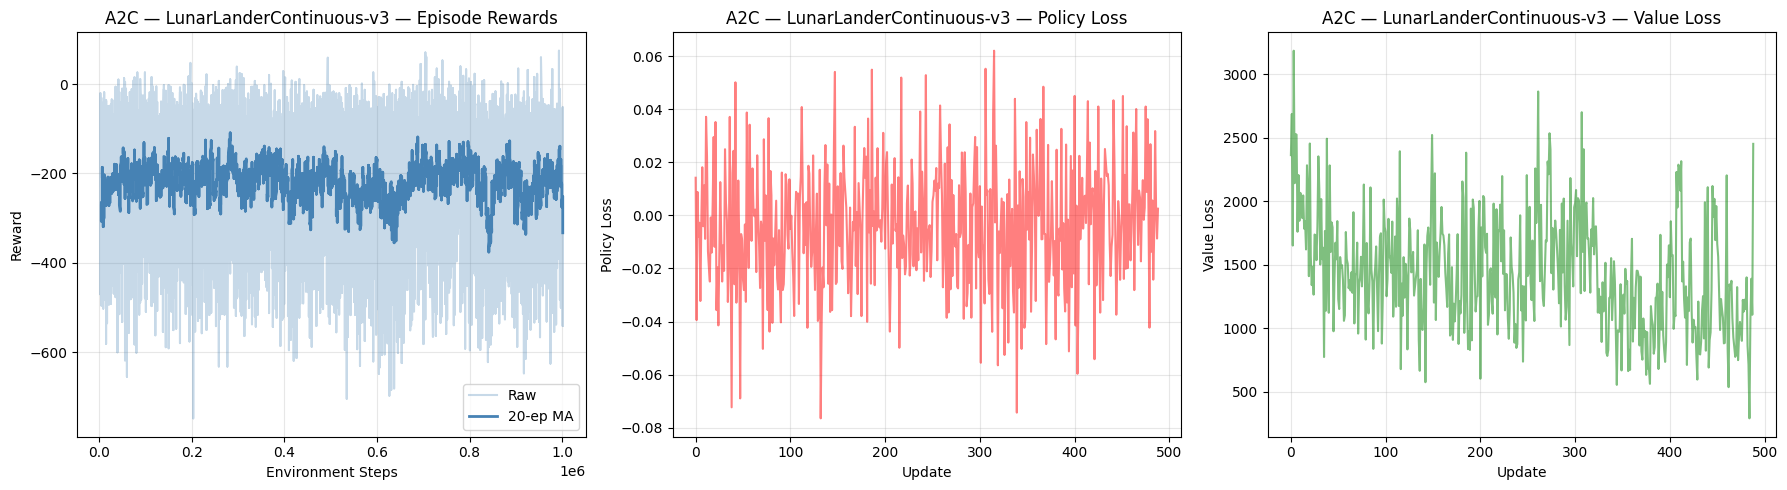


Average reward (last 50 episodes): -282.6


In [13]:
# A.6 — Train A2C on LunarLanderContinuous-v3
# Expected behaviour: A2C struggles — reward typically stays around -150 to -200.
# That is normal; the point is to observe the training dynamics before moving to SAC.
results_a2c = train_a2c(
    env_name        = "LunarLanderContinuous-v3",
    total_timesteps = 1_000_000,
    n_steps         = 2048,
    batch_size      = 64,
    lr              = 3e-4,
    gae_lambda      = 0.95,
    ent_coef        = 0.01,
    solve_threshold = 200.0,
    seed            = 42,
    log_interval    = 10,
)

plot_a2c_results(results_a2c,
                 title="A2C — LunarLanderContinuous-v3",
                 experiments_dir=EXPERIMENTS_DIR)

last_ep = results_a2c['episode_rewards'][-50:]
print(f"\nAverage reward (last 50 episodes): {np.mean(last_ep):.1f}")

In [16]:
# A.6 — Visualize the trained A2C agent
video_path = record_agent_video(
    results_a2c['agent'],
    env_name        = "LunarLanderContinuous-v3",
    agent_type      = "a2c",
    num_episodes    = 3,
    seed            = 0,
    name_prefix     = "a2c_lunar",
    experiments_dir = EXPERIMENTS_DIR,
)
if video_path:
    display(Video(video_path, embed=True, width=500))

Episode 1: reward = -119.1
Episode 2: reward = -152.4
Episode 3: reward = -115.8
Video saved → c:\Users\Jensw\Desktop\tdde78lab\labs\lab3_actor_critic\experiments\videos\a2c_lunar-episode-2.mp4


Step   10000 | Avg Reward (last 10):   -74.3 | Alpha: 0.3351
Step   20000 | Avg Reward (last 10):  -159.8 | Alpha: 0.1182
Step   30000 | Avg Reward (last 10):    29.1 | Alpha: 0.1081
Step   40000 | Avg Reward (last 10):    21.6 | Alpha: 0.0973
Step   50000 | Avg Reward (last 10):    19.7 | Alpha: 0.1095
Step   60000 | Avg Reward (last 10):    64.4 | Alpha: 0.0931
Step   70000 | Avg Reward (last 10):   123.7 | Alpha: 0.0871
Step   80000 | Avg Reward (last 10):   105.7 | Alpha: 0.0853
Step   90000 | Avg Reward (last 10):   173.4 | Alpha: 0.0881
Step  100000 | Avg Reward (last 10):   163.6 | Alpha: 0.0864
Solved! Average reward 205.4 >= 200.0
Plot saved → c:\Users\Jensw\Desktop\tdde78lab\labs\lab3_actor_critic\experiments\plots\sac__lunarlandercontinuous-v3.png


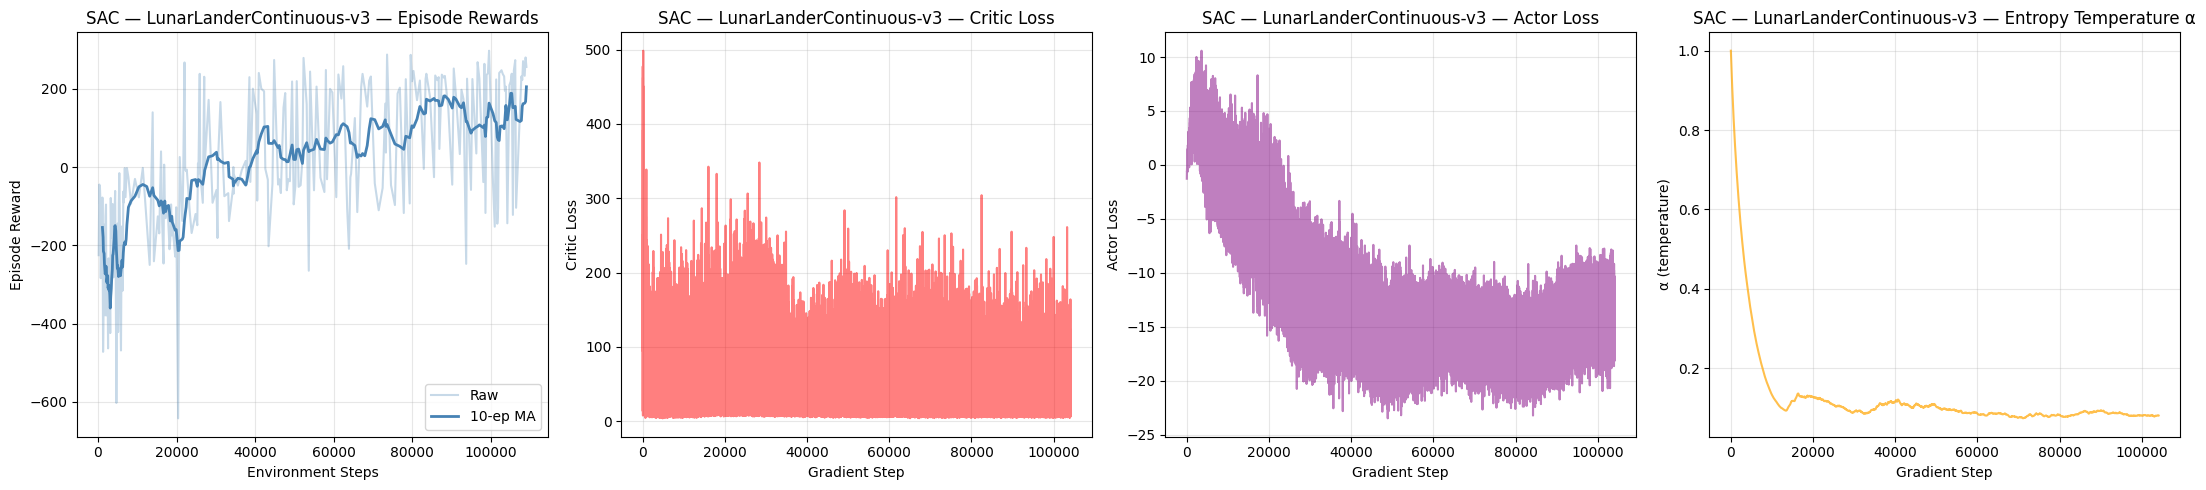


Average reward (last 10 episodes): 205.4
LunarLander SOLVED with SAC!


In [17]:
# A.7 — Train SAC on LunarLanderContinuous-v3
# Expected: SAC solves the environment in ~40k-50k steps (reward ≥ 200).
results_sac = train_sac(
    env_name        = "LunarLanderContinuous-v3",
    total_timesteps = 300_000,
    learning_starts = 5000,
    batch_size      = 256,
    lr              = 3e-4,
    tau             = 0.005,
    gamma           = 0.99,
    autotune_alpha  = True,
    solve_threshold = 200.0,
    seed            = 42,
    log_interval    = 10_000,
)

plot_sac_results(results_sac,
                 title="SAC — LunarLanderContinuous-v3",
                 experiments_dir=EXPERIMENTS_DIR)

last_ep = results_sac['episode_rewards'][-10:]
print(f"\nAverage reward (last 10 episodes): {np.mean(last_ep):.1f}")
if np.mean(last_ep) >= 200:
    print("LunarLander SOLVED with SAC!")

In [18]:
# A.7 — Visualize the trained SAC agent
video_path = record_agent_video(
    results_sac['agent'],
    env_name        = "LunarLanderContinuous-v3",
    agent_type      = "sac",
    num_episodes    = 3,
    seed            = 0,
    name_prefix     = "sac_lunar",
    experiments_dir = EXPERIMENTS_DIR,
)
if video_path:
    display(Video(video_path, embed=True, width=500))

Episode 1: reward = -14.6
Episode 2: reward = 236.0
Episode 3: reward = 247.5
Video saved → c:\Users\Jensw\Desktop\tdde78lab\labs\lab3_actor_critic\experiments\videos\sac_lunar-episode-2.mp4


---

# Part B — Experiments

For all experiments, run at least **3 random seeds** and report mean ± std.

---

## B.1 — Ablation: SAC Entropy Temperature

The entropy temperature α controls the exploration-exploitation trade-off in SAC.
Compare three settings: fixed α = 0.05 (low entropy), fixed α = 0.2 (moderate), and
auto-tuned α which adapts throughout training to match a target entropy level.

**Expected finding:** Auto-tuning should outperform fixed values because it provides
high exploration early and naturally decays as the policy converges.

In [ ]:
# B.1 — SAC entropy temperature ablation (3 seeds each)
seeds = [42, 123, 456]

entropy_results = {
    'Fixed alpha = 0.05': [
        train_sac(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=200_000,
            learning_starts=5000, batch_size=256,
            autotune_alpha=False, alpha=0.05, seed=s,
        )
        for s in seeds
    ],
    'Fixed alpha = 0.2': [
        train_sac(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=200_000,
            learning_starts=5000, batch_size=256,
            autotune_alpha=False, alpha=0.2, seed=s,
        )
        for s in seeds
    ],
    'Auto-tuned alpha': [
        train_sac(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=200_000,
            learning_starts=5000, batch_size=256,
            autotune_alpha=True, seed=s,
        )
        for s in seeds
    ],
}

plot_comparison(entropy_results,
                title="SAC Entropy Temperature Ablation — LunarLanderContinuous-v3",
                experiments_dir=EXPERIMENTS_DIR)

print("\nMean ± Std of average reward (last 20 episodes):")
for label, runs in entropy_results.items():
    last20 = [np.mean(r['episode_rewards'][-20:]) for r in runs]
    print(f"  {label}: {np.mean(last20):.1f} ± {np.std(last20):.1f}")

Step    5000 | Avg Reward (last 10):  -158.4 | Alpha: 0.0500
Step   10000 | Avg Reward (last 10):  -121.5 | Alpha: 0.0500
Step   15000 | Avg Reward (last 10):  -199.7 | Alpha: 0.0500
Step   20000 | Avg Reward (last 10):  -178.4 | Alpha: 0.0500
Step   25000 | Avg Reward (last 10):   -39.1 | Alpha: 0.0500
Step   30000 | Avg Reward (last 10):   -36.1 | Alpha: 0.0500
Step   35000 | Avg Reward (last 10):   -76.9 | Alpha: 0.0500
Step   40000 | Avg Reward (last 10):    33.8 | Alpha: 0.0500
Step   45000 | Avg Reward (last 10):    15.8 | Alpha: 0.0500
Step   50000 | Avg Reward (last 10):     9.3 | Alpha: 0.0500
Step   55000 | Avg Reward (last 10):    -1.1 | Alpha: 0.0500
Step   60000 | Avg Reward (last 10):    23.8 | Alpha: 0.0500
Step   65000 | Avg Reward (last 10):    27.9 | Alpha: 0.0500
Step   70000 | Avg Reward (last 10):    11.3 | Alpha: 0.0500
Step   75000 | Avg Reward (last 10):   -22.6 | Alpha: 0.0500
Step   80000 | Avg Reward (last 10):   -64.9 | Alpha: 0.0500
Step   85000 | Avg Rewar

## B.2 — Ablation: GAE Lambda in A2C

GAE lambda λ interpolates between one-step TD (λ = 0, low variance, high bias)
and Monte Carlo returns (λ = 1, no bias, high variance). Compare λ = 0.0, λ = 0.95
(default), and λ = 1.0 to observe the bias-variance trade-off in practice.

**Note:** Since A2C already struggles on this environment, differences between
λ values may be subtle — focus on any systematic trends across seeds.

Update     10 | Timesteps    20,480 | Avg Reward (last 10):  -207.7
Update     20 | Timesteps    40,960 | Avg Reward (last 10):  -158.4
Update     30 | Timesteps    61,440 | Avg Reward (last 10):  -272.3
Update     40 | Timesteps    81,920 | Avg Reward (last 10):  -265.0
Update     50 | Timesteps   102,400 | Avg Reward (last 10):  -331.5
Update     60 | Timesteps   122,880 | Avg Reward (last 10):  -185.2
Update     70 | Timesteps   143,360 | Avg Reward (last 10):  -216.3
Update     80 | Timesteps   163,840 | Avg Reward (last 10):  -253.6
Update     90 | Timesteps   184,320 | Avg Reward (last 10):  -263.2
Update    100 | Timesteps   204,800 | Avg Reward (last 10):  -309.2
Update    110 | Timesteps   225,280 | Avg Reward (last 10):  -320.4
Update    120 | Timesteps   245,760 | Avg Reward (last 10):  -193.6
Update    130 | Timesteps   266,240 | Avg Reward (last 10):  -213.8
Update    140 | Timesteps   286,720 | Avg Reward (last 10):  -437.7
Update    150 | Timesteps   307,200 | Avg Reward

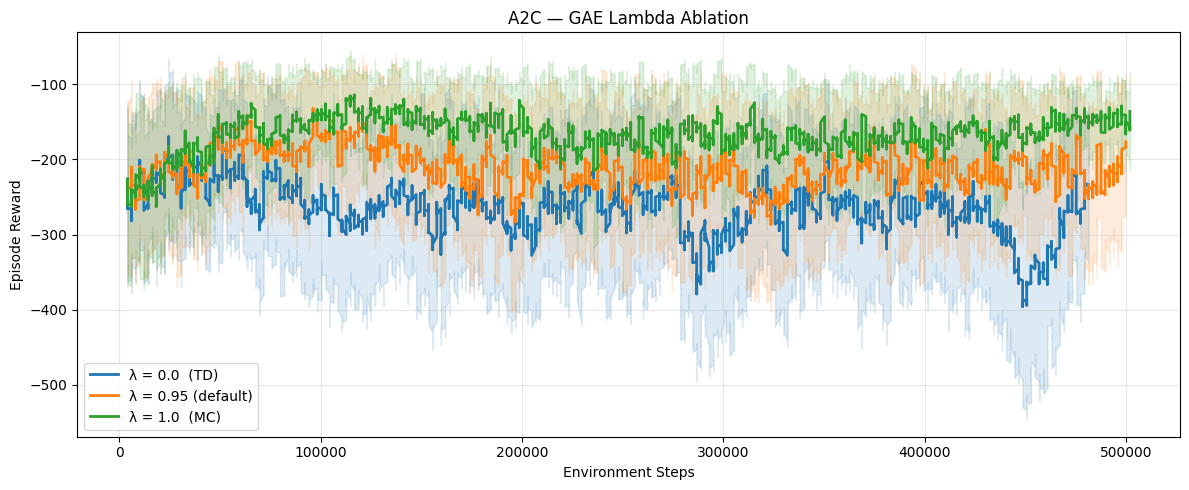


Mean ± Std of average reward (last 20 episodes):
  λ = 0.0  (TD): -230.9 ± 8.9
  λ = 0.95 (default): -206.1 ± 3.2
  λ = 1.0  (MC): -137.2 ± 14.5


In [8]:
# B.2 — GAE lambda ablation in A2C (3 seeds each)
seeds = [42, 123, 456]

lambda_results = {
    'λ = 0.0  (TD)': [
        train_a2c(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=500_000,
            n_steps=2048, batch_size=64, lr=3e-4,
            gae_lambda=0.0, ent_coef=0.01, seed=s,
        )
        for s in seeds
    ],
    'λ = 0.95 (default)': [
        train_a2c(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=500_000,
            n_steps=2048, batch_size=64, lr=3e-4,
            gae_lambda=0.95, ent_coef=0.01, seed=s,
        )
        for s in seeds
    ],
    'λ = 1.0  (MC)': [
        train_a2c(
            env_name='LunarLanderContinuous-v3',
            total_timesteps=500_000,
            n_steps=2048, batch_size=64, lr=3e-4,
            gae_lambda=1.0, ent_coef=0.01, seed=s,
        )
        for s in seeds
    ],
}

plot_comparison(lambda_results,
                title="A2C — GAE Lambda Ablation",
                experiments_dir=EXPERIMENTS_DIR)

print("\nMean ± Std of average reward (last 20 episodes):")
for label, runs in lambda_results.items():
    last20 = [np.mean(r['episode_rewards'][-20:]) for r in runs]
    print(f"  {label}: {np.mean(last20):.1f} ± {np.std(last20):.1f}")

---

## Summary

1. **A.6/A.7 — A2C vs SAC:** Describe the difference in learning behaviour between A2C and SAC on LunarLanderContinuous-v3. Which algorithm solves the environment, and approximately how many environment steps does it take?

Looking at the generated charts aswell as the video, A2C isn't getting it. The rewards stay low and flat, which means the lander never actually learns to land... The loss plots are all over the place with huge spikes, showing that the agent is not learning. Basically, the training is too messy and unstable for the agent to figure out a winning strategy.

Looking at the SAC charts, the agent is clearly succeeding. The rewards go up steadily and eventually hit the +200 goal, and the losses level out, showing that the training is stable! We can also see the alpha temperature drop, which means the agent stopped guessing and successfully focused on landing! This matches the video perfectly, which shows the rocket ship landing safely. So here we have a solution and it got solved in about aprox 100,000 env steps.

2. **B.1 — SAC entropy temperature:** Which α setting performed best? Describe how the entropy temperature affects exploration and why auto-tuning outperforms fixed values.

The auto-tuned alfa performed best, alfa = 0.2 also gave good results. The lowest setting, alfa = 0.05, performed much worse and was quite unstable.
alfa controls how random the agent’s actions are. A higher alfa means more exploration, and lower makes the agent more focused on what it already thinks is best.
In the results, alfa = 0.05 did not explore enough, so the agent often got stuck. With alfa = 0.2, the agent explored more and got better rewards.

Auto-tuning works better because it adjusts alfa over time. Early in training, it keeps alfa higher to encourage exploration, and later it lowers it so the agent can focus on the best set of actions found.

3. **B.2 — GAE lambda in A2C:** Which λ value worked best? Describe the bias-variance trade-off — what happens at the extremes (λ = 0 and λ = 1)?

From the data in the graph it seems λ = 1 gives the best result but there is not too much differance in the outcomes. In the previous lab λ = 0.95 gave the best result but that was with respect to the cartpole enviroment. 
λ = 1 gave the best trade-off between bias and variance. it seems that in the LunarLander-env, getting the full return seems more important than reducing noise. So even though it’s noisier, it results in a better policy!

λ = 0, low variance but high bias, so learning can become less accurate. 
λ = 1, high variance, making learning noisier and less stable. 
λ = 0.95, balancing variance and bias



---

**Lab designed by Amath Sow:** [amath.sow@liu.se](mailto:amath.sow@liu.se)

**TDDE78 — Deep Reinforcement Learning, Linköping University — Spring 2026**